In [1]:
%pip install umap-learn


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# IMPORTS

import pandas as pd
import numpy as np
import pickle
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, learning_curve
from sklearn.manifold import TSNE, trustworthiness
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import warnings
warnings.filterwarnings("ignore")

# for consistent uncertainty transformation
from uncertainty_transformer import UncertaintyTransformer

In [3]:
# CONSTANTS

EXCEL_PATH = "copy_Miyokardit_08.12.2025.xlsx"
LABEL_COL  = "GRUP"
from uncertainty_utils import EPS
from uncertainty_utils import N_BINS

In [4]:
# HELPER CLASS
from uncertainty_utils import (
    discretise,
    get_distribution,
    shannon_entropy,
    js_divergence,
)

In [5]:
df = pd.read_excel(EXCEL_PATH)

LABEL_COL = "GRUP"

label_series = df[LABEL_COL]

df_part1 = df.iloc[:, 6:37]   # AGE..Recent Infection(4 hafta)
df_part2 = df.iloc[:, 41:61]  # TROP_KATSAYISI..HDL
df_part3 = df.iloc[:, 63:64]  # hs-CRP_KATSAYISI
df_part4 = df.iloc[:, 68:78]  # EF..ECG_Q waves
df = pd.concat([df_part1, df_part2, df_part3, df_part4], axis=1)

# manually exclude columns bcs. of mismatch in 2 datasets
COLS_TO_EXCLUDE = [
    'HIPERTIROIDI',
    'HIPOTIROIDI',
    'Mental Health History',
    'PAH',
    'ROMATOLOJIK_HASTALIK',
    'Socioeconomic Status',
    'PEAK_TROP',
]
df = df.drop(columns=[c for c in COLS_TO_EXCLUDE if c in df.columns])

print("After feature selection shape:", df.shape)

# hidden NaN filtering
df = df.replace([" ", "", "-", "--", "nan", "NaN", "None",
                 "#VALUE!", "#N/A", "#REF!", "#DIV/0!", "#NUM!", "#NAME?", "#NULL!"], pd.NA)
df = df.apply(lambda col: col.replace(r'^\s*$', pd.NA, regex=True))

datetime_cols = df.select_dtypes(include=["datetime"]).columns
df = df.drop(columns=datetime_cols)

for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[LABEL_COL] = label_series

After feature selection shape: (184, 55)


In [6]:
# train/test split

X_raw = df.drop(columns=[LABEL_COL]).copy()
y = df[LABEL_COL].values

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

print("Train size:", len(X_train_raw))
print("Test size :", len(X_test_raw))

# save split indices to disk for reuse in finetuning notebook
split_indices = {
    'train_idx': X_train_raw.index.tolist(),
    'test_idx': X_test_raw.index.tolist(),
    'random_state': 42,
    'test_size': 0.2
}
with open('split_indices.pkl', 'wb') as f:
    pickle.dump(split_indices, f)

print("Split indices saved to: split_indices.pkl")


Train size: 147
Test size : 37
Split indices saved to: split_indices.pkl


In [7]:
# ============================================================================
# PREPROCESSING
# ============================================================================

print("="*80)
print("PREPROCESSING: ELIMINATE NaN VALUES")
print("="*80)

NAN_COL_THRESHOLD = 0.20  # drop columns with more than 20% NaN in training set

# reconstruct df_train and df_test from split indices
df_train = df.loc[X_train_raw.index].copy()
df_test = df.loc[X_test_raw.index].copy()

print(f"\n[STEP 1: ELIMINATE COLUMNS WITH >{int(NAN_COL_THRESHOLD*100)}% NaN VALUES]")

nan_pct_train = df_train.drop(columns=[LABEL_COL]).isna().mean()
cols_to_drop = nan_pct_train[nan_pct_train > NAN_COL_THRESHOLD].index

if len(cols_to_drop) > 0:
    print(f"  Dropping {len(cols_to_drop)} columns:")
    for col in cols_to_drop:
        print(f"    • {col}: {nan_pct_train[col]*100:.1f}% NaN")
    df_train = df_train.drop(columns=cols_to_drop)
    df_test = df_test.drop(columns=cols_to_drop, errors='ignore')
else:
    print("  No columns exceed threshold - all features kept")

print(f"\n  Training set: {df_train.shape[1]-1} features remaining")
print(f"  Test set:     {df_test.shape[1]-1} features remaining")

print("\n[STEP 2: ELIMINATE ROWS WITH NaN VALUES]")

# training set
initial_train = len(df_train)
df_train = df_train.dropna(axis=0)
final_train = len(df_train)
dropped_train = initial_train - final_train

print(f"  Training set:")
print(f"    Initial: {initial_train} samples")
print(f"    Dropped: {dropped_train} rows with NaN values")
print(f"    Final: {final_train} samples")

# test set
initial_test = len(df_test)
df_test = df_test.dropna(axis=0)
final_test = len(df_test)
dropped_test = initial_test - final_test

print(f"\n  Test set:")
print(f"    Initial: {initial_test} samples")
print(f"    Dropped: {dropped_test} rows with NaN values")
print(f"    Final: {final_test} samples")

print("\n[STEP 3: VERIFICATION]")

train_nans = df_train.isna().sum().sum()
test_nans = df_test.isna().sum().sum()

if train_nans == 0 and test_nans == 0:
    print(f"   SUCCESS: Zero NaN values in both sets")
    print(f"     Training: {len(df_train)} complete samples")
    print(f"     Test: {len(df_test)} complete samples")
    print(f"     Clinical data integrity: All samples have complete measurements")
else:
    print(f"   ERROR: Unexpected NaN values still present")
    print(f"     Training NaNs: {train_nans}")
    print(f"     Test NaNs: {test_nans}")
    raise ValueError("NaN values still present after elimination - check preprocessing")

# define features from cleaned df_train
features = df_train.select_dtypes(include=["int", "float"]).columns.tolist()
features = [f for f in features if f != LABEL_COL]
features = sorted(features)

# create final datasets
X_train_raw = df_train[features].copy()
y_train = df_train[LABEL_COL].values
X_test_raw = df_test[features].copy()
y_test = df_test[LABEL_COL].values

df_clean = pd.concat([df_train, df_test], axis=0)  # for visualization

# calculate class distribution
final_class_counts = df_clean[LABEL_COL].value_counts().sort_index()

print(f"\n{'='*80}")
print("SUMMARY")
print("="*80)
print(f"\nFinal clean data:")
print(f"  Training: {len(df_train)} samples × {len(features)} features")
print(f"  Test: {len(df_test)} samples × {len(features)} features")
print(f"  Total: {len(df_clean)} complete clinical records")

print(f"\nClass distribution:")
for label, count in final_class_counts.items():
    print(f"  Class {label}: {count} patients")
print(f"{'='*80}\n")

PREPROCESSING: ELIMINATE NaN VALUES

[STEP 1: ELIMINATE COLUMNS WITH >20% NaN VALUES]
  Dropping 1 columns:
    • ALBUMIN: 44.9% NaN

  Training set: 54 features remaining
  Test set:     54 features remaining

[STEP 2: ELIMINATE ROWS WITH NaN VALUES]
  Training set:
    Initial: 147 samples
    Dropped: 21 rows with NaN values
    Final: 126 samples

  Test set:
    Initial: 37 samples
    Dropped: 5 rows with NaN values
    Final: 32 samples

[STEP 3: VERIFICATION]
   SUCCESS: Zero NaN values in both sets
     Training: 126 complete samples
     Test: 32 complete samples
     Clinical data integrity: All samples have complete measurements

SUMMARY

Final clean data:
  Training: 126 samples × 54 features
  Test: 32 samples × 54 features
  Total: 158 complete clinical records

Class distribution:
  Class 1: 61 patients
  Class 2: 97 patients



In [8]:

print(features)


['AGE', 'ALT', 'AST', 'Any Previous Pain Attacks', 'Arm Pain', 'Back Pain', 'CK-MB', 'Chest Pain', 'Chest Pain Character', 'Chest Pain Duration(saat)', 'DM', 'Dyspnea', 'ECG_Location of ST depression ', 'ECG_Location of T negativity', 'ECG_Q waves', 'ECG_ST depression', 'ECG_T neg', 'EF', 'EOSpik', 'Epigastric Pain', 'FH', 'Fatigue', 'GLUKOZ', 'HB', 'HDL', 'HL', 'HT', 'HTC', 'KBY', 'KOAH', 'KREATIN', 'LDL', 'LYMPpik', 'Level of ST-Dep_mm', 'Level of T invertion_mm', 'MONOpik', 'NEUpik', 'Nausea', 'PLT', 'PRIOR_KAH', 'Pericardial Effusion', 'Radiation', 'Recent Infection(4 hafta)', 'Relation with Position', 'Relation with exercise', 'SEX', 'SIGARA', 'Segmentary Wall Motion Abnormality', 'TG', 'TOTAL_KOLESTEROL', 'TROP_KATSAYISI', 'WBCpik', 'hs-CRP_KATSAYISI', 'Çarpıntı']


In [9]:
# ============================================================================
# PREPROCESSING VERIFICATION
# ============================================================================

print("="*80)
print("PREPROCESSING VERIFICATION")
print("="*80)

# check for NaNs in final datasets
train_nans = X_train_raw.isna().sum().sum()
test_nans = X_test_raw.isna().sum().sum()

print(f"\nNaN Check:")
print(f"  Training set NaNs: {train_nans}")
print(f"  Test set NaNs: {test_nans}")

if train_nans == 0 and test_nans == 0:
    print("\n  Zero NaN values in both sets")
else:
    print("\n  NaN values found - this should not happen")
    print(f"     Training NaNs: {train_nans}")
    print(f"     Test NaNs: {test_nans}")
    raise ValueError("NaN values detected - preprocessing failed")

print(f"\nDataset Sizes:")
print(f"  Training: {len(X_train_raw)} samples × {len(features)} features")
print(f"  Test: {len(X_test_raw)} samples × {len(features)} features")
print(f"  Total: {len(X_train_raw) + len(X_test_raw)} complete clinical records")

print(f"\nClass Balance:")
train_class_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
test_class_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()
for cls in sorted(pd.Series(y_train).unique()):
    train_pct = train_class_dist.get(cls, 0) * 100
    test_pct = test_class_dist.get(cls, 0) * 100
    print(f"  Class {cls}: Train {train_pct:.1f}%, Test {test_pct:.1f}%")

print("="*80)

PREPROCESSING VERIFICATION

NaN Check:
  Training set NaNs: 0
  Test set NaNs: 0

  Zero NaN values in both sets

Dataset Sizes:
  Training: 126 samples × 54 features
  Test: 32 samples × 54 features
  Total: 158 complete clinical records

Class Balance:
  Class 1: Train 37.3%, Test 43.8%
  Class 2: Train 62.7%, Test 56.2%


In [10]:
# ============================================================================
# MANUAL UNCERTAINTY MATRIX COMPUTATION (FOR VISUALIZATION)
# ============================================================================

print("="*80)
print("COMPUTING UNCERTAINTY MATRIX FOR VISUALIZATION")
print("="*80)
print(f"Using df_train (cleaned): {len(df_train)} samples")
print(f"This is for t-SNE/PCA visualization only")
print(f"CV evaluation uses X_train_raw: {len(X_train_raw)} samples")
print("="*80 + "\n")

# 3-a) Distributions, entropies (per class) and JS divergence (per feature)

dist      = {}       # {feat: (p_class1, p_class2)}
entropy   = {}       # {feat: {1: H1 , 2: H2}}
js        = {}       # {feat: JS}

for feat in features:
    col_disc = discretise(df_train[feat])
    p1 = get_distribution(col_disc[df_train[LABEL_COL] == 1])
    p2 = get_distribution(col_disc[df_train[LABEL_COL] == 2])

    dist[feat]    = (p1, p2)
    entropy[feat] = {1: shannon_entropy(p1, eps=EPS),
                     2: shannon_entropy(p2, eps=EPS)}
    js[feat]      = max(js_divergence(p1, p2, eps=EPS), EPS)    # never let it be 0

# 3-b) Means & stds for z-scores  (ddof=0 ⇒ population σ)
stats = {feat: {
               1: {"mu": df_train.loc[df_train[LABEL_COL] == 1, feat].mean(),
                   "std": df_train.loc[df_train[LABEL_COL] == 1, feat].std(ddof=0) + EPS},
               2: {"mu": df_train.loc[df_train[LABEL_COL] == 2, feat].mean(),
                   "std": df_train.loc[df_train[LABEL_COL] == 2, feat].std(ddof=0) + EPS}}
         for feat in features}

# ------------------------------------------------------------------------------------------------
# 4. Build the patient × feature matrix (for visualization)
# ------------------------------------------------------------------------------------------------

rows = []        # list of X-vectors
for _, patient in df_train.iterrows():
    vec = []
    for feat in features:
        v = patient[feat]

        # z-scores vs. each class
        z1 = (v - stats[feat][1]["mu"]) / stats[feat][1]["std"]
        z2 = (v - stats[feat][2]["mu"]) / stats[feat][2]["std"]

        # pick the *magnitude-wise* smaller one (ties go to class 1, matching UncertaintyTransformer)
        if abs(z1) <= abs(z2):
            z  = z1
            cls = 1
        else:
            z  = z2
            cls = 2

        h      = entropy[feat][cls]       # Shannon entropy of the chosen class
        js_f   = js[feat]                 # JS divergence for this feature
        # Formula matches UncertaintyTransformer: z * (entropy / (js + eps))
        x_f    = z * (h / (js_f + EPS))

        vec.append(x_f)
    rows.append(vec)

X_train_unc = pd.DataFrame(rows, index=df_train.index, columns=features)

print(f"Uncertainty matrix for visualization: {X_train_unc.shape}\n")


COMPUTING UNCERTAINTY MATRIX FOR VISUALIZATION
Using df_train (cleaned): 126 samples
This is for t-SNE/PCA visualization only
CV evaluation uses X_train_raw: 126 samples

Uncertainty matrix for visualization: (126, 54)



In [11]:
# little check (not needed)

for feat in features:
    std1 = stats[feat][1]["std"]
    std2 = stats[feat][2]["std"]
    if std1 == 0 or std2 == 0:
        print(f"Feature '{feat}' has zero std in class {1 if std1 == 0 else 2}")

In [12]:
X_train_unc

,AGE,ALT,AST,Any Previous Pain Attacks,Arm Pain,Back Pain,CK-MB,Chest Pain,Chest Pain Character,Chest Pain Duration(saat),...,Relation with exercise,SEX,SIGARA,Segmentary Wall Motion Abnormality,TG,TOTAL_KOLESTEROL,TROP_KATSAYISI,WBCpik,hs-CRP_KATSAYISI,Çarpıntı
159,3.663210,-10.180663,-6.902360,-0.0,-1.776469,-0.0,-19.632017,-0.0,2.692522,-5.801820,...,-0.0,27.008051,-4.273744,-2.216213,-5.151567,-1.230509,-5.058931,21.428621,-3.280693,-114.450502
42,-2.028217,-1.773635,-0.384994,-0.0,-1.776469,-0.0,9.857887,-0.0,-0.298794,4.733533,...,-0.0,27.008051,-4.273744,-2.216213,-7.835900,0.240770,-4.864072,6.361850,-4.751507,-114.450502
64,-0.722378,3.003100,-5.244954,-0.0,-1.776469,-0.0,-22.120228,-0.0,-0.298794,-0.353994,...,-0.0,27.008051,-4.273744,-2.216213,2.672297,-6.392856,-5.392975,-20.589322,-4.552514,-114.450502
12,-4.639893,-40.251232,-10.217171,-0.0,-1.776469,-0.0,-20.184953,-0.0,-0.298794,0.935933,...,-0.0,27.008051,-4.273744,-2.216213,-10.087656,-12.636269,-4.864072,-9.141037,-4.578470,-114.450502
160,3.663210,-24.315425,-3.035080,-0.0,-1.776469,-0.0,4.328530,-0.0,2.692522,-7.617762,...,-0.0,27.008051,1.880900,-2.216213,-4.990645,11.868738,-1.551471,3.264064,-4.578470,-114.450502
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,0.030654,50.810520,13.737716,-0.0,-1.776469,-0.0,137.954657,-0.0,2.692522,-6.528197,...,-0.0,27.008051,-4.273744,-2.216213,0.420541,17.039494,2.125559,1.750351,-0.382324,-114.450502
129,-1.180197,-4.575978,-6.349891,-0.0,-1.776469,-0.0,-22.332186,-0.0,-0.298794,-0.353994,...,-0.0,27.008051,1.880900,-2.216213,-6.584924,-11.465629,-6.562128,-3.178388,-4.491952,-114.450502
96,-3.601901,-22.038881,0.056341,-0.0,-1.776469,-0.0,8.014768,-0.0,-0.298794,-6.891385,...,-0.0,27.008051,1.880900,-2.216213,-0.580240,-18.879681,-2.358744,4.020920,-1.853138,-114.450502
44,-2.028217,-26.591969,-10.217171,-0.0,-1.776469,-0.0,-10.416422,-0.0,-0.298794,4.733533,...,-0.0,27.008051,1.880900,-2.216213,-3.082192,-5.711830,7.153833,-27.903505,-1.550323,-114.450502


In [13]:
# sanity check

print("NaNs per feature:")
display(X_train_unc.isna().sum().sort_values(ascending=False).head())

print("\nPatients with any NaN:")
na_rows = X_train_unc.isna().any(axis=1).sum()
print(f"{na_rows} / {len(X_train_unc)} patients contain at least one NaN")

NaNs per feature:


AGE                     0
Pericardial Effusion    0
KOAH                    0
KREATIN                 0
LDL                     0
dtype: int64


Patients with any NaN:
0 / 126 patients contain at least one NaN


In [14]:
_tsne_scaler = StandardScaler()
X_scaled = _tsne_scaler.fit_transform(X_train_unc)

X_scaled.shape

(126, 54)

In [15]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

tw_pca = trustworthiness(X_scaled, X_pca, n_neighbors=30)
print(tw_pca)

[0.1003256  0.08221437]
0.763216011042098


In [16]:
import umap
from sklearn.manifold import trustworthiness

umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X_scaled)

# Compute trustworthiness (default n_neighbors = 15)
tw_umap = trustworthiness(X_scaled, X_umap, n_neighbors=5)

print(f"UMAP Trustworthiness: {tw_umap:.3f}")

UMAP Trustworthiness: 0.796


In [17]:
# try out runs

best_run = None
for perp in [10, 20, 30, 40, 50]:
    tsne = TSNE(n_components=2, perplexity=perp, init="pca",
                learning_rate="auto", n_iter=3000, random_state=42)
    X_emb = tsne.fit_transform(X_scaled)
    tw    = trustworthiness(X_scaled, X_emb, n_neighbors=perp)
    print(f"perp {perp:>2}: trust = {tw:.3f}, KL = {tsne.kl_divergence_:.3f}")
    if best_run is None or tw > best_run["tw"]:
        best_run = dict(perp=perp, tw=tw, kl=tsne.kl_divergence_, emb=X_emb)

perp 10: trust = 0.772, KL = 0.698
perp 20: trust = 0.739, KL = 0.561
perp 30: trust = 0.757, KL = 0.484
perp 40: trust = 0.764, KL = 0.384
perp 50: trust = 0.786, KL = 0.326


In [18]:
NEIGHBOURS = 50

tsne = TSNE(n_components=1, perplexity=NEIGHBOURS, learning_rate='auto',
            init='pca', random_state=42)
X_tsne1 = tsne.fit_transform(X_scaled)

tw1 = trustworthiness(X_scaled, X_tsne1, n_neighbors=NEIGHBOURS)
print(f"Trustworthiness (k={NEIGHBOURS}): {tw1:.3f}")             # ≥ 0.9 is generally good
print(f"t-SNE KL divergence : {tsne.kl_divergence_:.4f}")


Trustworthiness (k=50): 0.712
t-SNE KL divergence : 0.4807


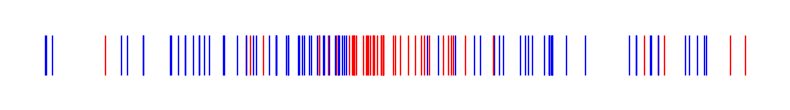

In [19]:

x1d = X_tsne1.ravel()
labels = df_train.loc[X_train_unc.index, LABEL_COL].to_numpy()

# map class → colour (same scheme as before)
colormap = {1: "red", 2: "blue"}
cols     = [colormap[l] for l in labels]

# ───────────────────────── 1-D coloured line ─────────────────────────────
fig, ax = plt.subplots(figsize=(8, 1.2))

# one tick per point: marker "|" is a short vertical line
ax.scatter(
    x1d, np.zeros_like(x1d),      # y = 0 ⇒ *no* second dimension
    c=cols, marker="|", s=800,    # s controls length & thickness
    linewidths=1
)

ax.set_axis_off()                # kill all axes, ticks, spines
plt.tight_layout()
plt.show()


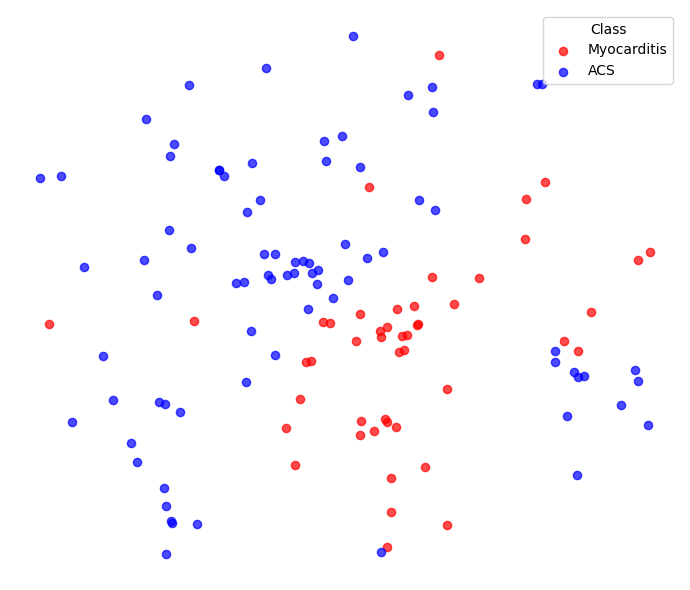

In [20]:
tsne = TSNE(n_components=2, perplexity=50, learning_rate='auto',
            init='pca', random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

labels = df_train.loc[X_train_unc.index, LABEL_COL].to_numpy()

plt.figure(figsize=(7,6))

# Plot each class separately with label for legend
for cls, color in zip([1, 2], ['red', 'blue']):
    idx = labels == cls
    if cls == 1:
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                c=color, label=f'Myocarditis', s=35, alpha=0.7)
    if cls == 2:
        plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1],
                c=color, label=f'ACS', s=35, alpha=0.7)


plt.xlabel('t-SNE-1')
plt.ylabel('t-SNE-2')
#plt.title(f't-SNE projection of the uncertainty matrix X')

plt.gca().set_axis_off()

plt.legend(title="Class", loc='best')
plt.tight_layout()

plt.savefig("tSNE.pdf", dpi=300)
plt.show()

In [21]:
# Save embedding for app.py — single source of truth
# X_scaled = normalized uncertainty matrix (for kNN patient positioning)
# X_tsne   = 2D t-SNE coords (for landscape + patient positioning)
# labels   = class labels
# _tsne_scaler = the StandardScaler used, so app can project new patients consistently
import os, numpy as np, pickle
os.makedirs("app_artifacts", exist_ok=True)
np.savez(
    "app_artifacts/embedding_data.npz",
    X_std=X_scaled,
    X_emb=X_tsne.astype(np.float32),
    y=labels,
)
with open("app_artifacts/tsne_scaler.pkl", "wb") as f:
    pickle.dump(_tsne_scaler, f)
print(f"Saved: app_artifacts/embedding_data.npz  ({len(X_tsne)} samples)")
print(f"Saved: app_artifacts/tsne_scaler.pkl")

Saved: app_artifacts/embedding_data.npz  (126 samples)
Saved: app_artifacts/tsne_scaler.pkl


In [22]:
X_tsne.shape

(126, 2)

In [23]:

plt.rcParams["figure.figsize"] = (7, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 12


In [24]:
# Padding around extreme points so contours don't touch the frame
pad = 2.0

xmin, xmax = X_tsne[:, 0].min() - pad, X_tsne[:, 0].max() + pad
ymin, ymax = X_tsne[:, 1].min() - pad, X_tsne[:, 1].max() + pad

# 250×250 grid (adjust for speed ↔ smoothness)
resolution = 1000
xs = np.linspace(xmin, xmax, resolution)
ys = np.linspace(ymin, ymax, resolution)
xx, yy = np.meshgrid(xs, ys)
grid = np.vstack([xx.ravel(), yy.ravel()])


In [25]:
class1 = X_tsne[labels == 1]
class2 = X_tsne[labels == 2]

kde1 = gaussian_kde(class1.T, bw_method="scott")
kde2 = gaussian_kde(class2.T, bw_method="scott")

z1 = kde1(grid).reshape(xx.shape)
z2 = kde2(grid).reshape(xx.shape)


In [26]:
z1[2,5]

np.float64(2.709910980329043e-17)

In [27]:
q = 0.6                                                     # 60 % iso-density
level1 = np.quantile(z1, q)
level2 = np.quantile(z2, q)

overlap = (z1 >= level1) & (z2 >= level2)

In [28]:
# --- 6.  Build alpha masks & colour-shift for the overlap -----------------
def normalise(z, clip=0.98):
    """Scale density field to 0–1, clipping the top `clip` quantile."""
    zmax = np.quantile(z, clip)
    return np.clip(z / zmax, 0, 1)

# -------------------------------------------------------------------------
# 1) Alpha masks for the *pure* class regions (same idea as before)
# -------------------------------------------------------------------------
alpha1 = normalise(z1)**0.5
alpha2 = normalise(z2)**0.5
alpha1[z1 < level1] = 0.0
alpha2[z2 < level2] = 0.0

# -------------------------------------------------------------------------
# 2) Identify the overlap and give it its own alpha map
# -------------------------------------------------------------------------
overlap_mask      = (alpha1 > 0) & (alpha2 > 0)
alpha_overlap     = np.maximum(alpha1, alpha2)
alpha_overlap[~overlap_mask] = 0.0

# Remove the red/blue alphas *inside* the overlap so they don't sit on top
alpha1[overlap_mask] = 0.0
alpha2[overlap_mask] = 0.0

# -------------------------------------------------------------------------
# 3) Per-pixel colour for the overlap
#    • Start from mid-grey  (0.5, 0.5, 0.5)
#    • Shift toward red or blue according to local dominance
# -------------------------------------------------------------------------
eps   = 1e-12                    # avoid division by zero
total = z1 + z2 + eps
t     = (z1 - z2) / total        # -1 ⟶ pure blue side, +1 ⟶ pure red side

shift_strength = 0.3    # 0 → always grey, base_gray → full red/blue at edge

# Base: all grey
R = np.full_like(t, 0.5)
G = np.full_like(t, 0.5)
B = np.full_like(t, 0.5)

# Shift toward red where t > 0
pos          = t > 0
R[pos] += shift_strength * t[pos]
G[pos] -= shift_strength * t[pos]
B[pos] -= shift_strength * t[pos]

# Shift toward blue where t < 0
neg          = t < 0
B[neg] += shift_strength * (-t[neg])
R[neg] -= shift_strength * (-t[neg])
G[neg] -= shift_strength * (-t[neg])

shape = (*alpha1.shape, 4)        # (Ny, Nx, 4)

red_img  = np.zeros(shape)
red_img[..., 0] = 1.0             # R channel
red_img[..., 3] = alpha1          # alpha   (class-1 density)

blue_img = np.zeros(shape)
blue_img[..., 2] = 1.0            # B channel
blue_img[..., 3] = alpha2         # alpha   (class-2 density)

# Build the RGBA image for the overlap
shape      = (*alpha_overlap.shape, 4)
over_img   = np.zeros(shape)
over_img[..., 0] = R
over_img[..., 1] = G
over_img[..., 2] = B
over_img[..., 3] = alpha_overlap        # density-weighted fade-out


Saved: app_artifacts/diagnostic_landscape.png


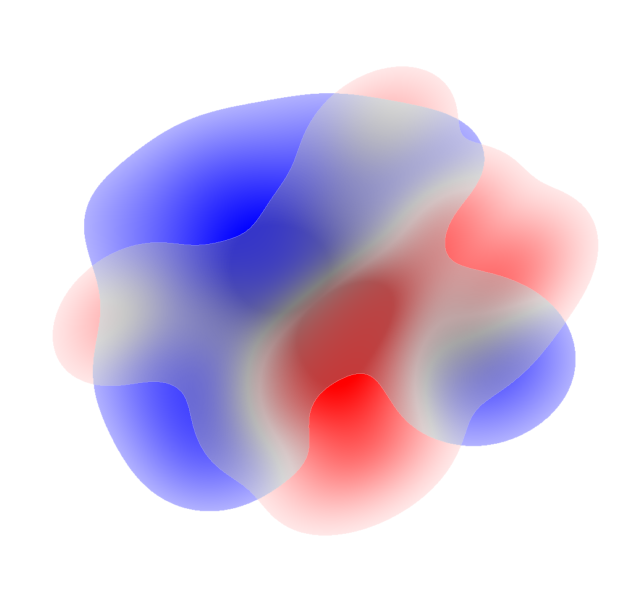

In [29]:
# --- Plot, final clean look ----------------------------------------------
fig, ax = plt.subplots()

# Filled RGBA layers (unchanged)
for img in [over_img, red_img, blue_img]:
    ax.imshow(img, extent=(xmin, xmax, ymin, ymax), origin="lower", interpolation="bilinear")

ax.set_axis_off()

plt.tight_layout()
plt.savefig("viz.pdf", dpi=300)

# Save for app welcome screen (no legend — plotly overlay provides the legend)
import os
os.makedirs("app_artifacts", exist_ok=True)
fig.savefig("app_artifacts/diagnostic_landscape.png", dpi=150, bbox_inches="tight", facecolor="white")
print("Saved: app_artifacts/diagnostic_landscape.png")

plt.show()

In [30]:
# class distribution
print(df_clean[LABEL_COL].value_counts())
print(df_clean[LABEL_COL].value_counts(normalize=True))

GRUP
2    97
1    61
Name: count, dtype: int64
GRUP
2    0.613924
1    0.386076
Name: proportion, dtype: float64


In [31]:
# ============================================================================
# Baseline Models
# ============================================================================

baseline_models = {
    "k-NN (k = 15)": KNeighborsClassifier(n_neighbors=15),
    "Random Forest": RandomForestClassifier(
      n_estimators=300,
      max_depth=4,
      min_samples_leaf=5,
      min_samples_split=10,
      max_features=0.5,
      class_weight="balanced",
      random_state=42
    ),
    "SVC (RBF)":     SVC(kernel="rbf", probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=3000)
}

def make_baseline_pipeline(model):
    """
    Create a pipeline with UncertaintyTransformer, StandardScaler, and model.
    
    Parameters
    ----------
    model : classifier
        The classifier to use in the pipeline.
        How to handle NaN values:
        - 'error': Raise error if NaNs detected
        - 'warn': Replace with 0 and issue warning
        - 'zero': Silently replace with 0
    """
    return Pipeline([
        ("uncertainty", UncertaintyTransformer(
            feature_names=features,
            class_labels=None,
            n_bins=N_BINS,
            eps=EPS,
        )),
        ("scaler", StandardScaler()),
        ("clf", model),
    ])

print("Baseline models defined:")
for name in baseline_models.keys():
    print(f"  - {name}")

Baseline models defined:
  - k-NN (k = 15)
  - Random Forest
  - SVC (RBF)
  - Logistic Regression


In [32]:
# IMPORTS

from sklearn.model_selection import cross_validate

In [33]:
# ============================================================================
# Baseline Model Evaluation
# ============================================================================
# 5-fold CV for every model
# only on TRAIN

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_results = []

for model_name, model in baseline_models.items():
    print(f"\nEvaluating {model_name}...")
    
    pipeline = make_baseline_pipeline(model)
    
    cv_results = cross_validate(
        pipeline,
        X_train_raw,
        y_train,
        cv=cv,
        scoring={
            'accuracy': 'accuracy',
            'precision_macro': 'precision_macro',
            'recall_macro': 'recall_macro',
            'f1_macro': 'f1_macro'
        },
        return_train_score=False, 
        n_jobs=-1
    )
    
    # store results
    baseline_results.append({
        'Model': model_name,
        'Accuracy': f"{cv_results['test_accuracy'].mean():.3f} ± {cv_results['test_accuracy'].std():.3f}",
        'Precision (macro)': f"{cv_results['test_precision_macro'].mean():.3f} ± {cv_results['test_precision_macro'].std():.3f}",
        'Recall (macro)': f"{cv_results['test_recall_macro'].mean():.3f} ± {cv_results['test_recall_macro'].std():.3f}",
        'F1 (macro)': f"{cv_results['test_f1_macro'].mean():.3f} ± {cv_results['test_f1_macro'].std():.3f}",
        '_recall_mean': cv_results['test_recall_macro'].mean(),
    })

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df.sort_values('_recall_mean', ascending=False)
baseline_results_df = baseline_results_df.drop(columns=['_recall_mean'])

print("\n" + "="*80)
print("BASELINE MODEL RESULTS (5-Fold Stratified CV on TRAIN)")
print("="*80)
print(baseline_results_df.to_string(index=False))
print("="*80)


Evaluating k-NN (k = 15)...

Evaluating Random Forest...

Evaluating SVC (RBF)...

Evaluating Logistic Regression...

BASELINE MODEL RESULTS (5-Fold Stratified CV on TRAIN)
              Model      Accuracy Precision (macro) Recall (macro)    F1 (macro)
Logistic Regression 0.944 ± 0.074     0.941 ± 0.080  0.937 ± 0.086 0.938 ± 0.083
      Random Forest 0.913 ± 0.039     0.918 ± 0.041  0.895 ± 0.050 0.903 ± 0.047
      k-NN (k = 15) 0.904 ± 0.074     0.914 ± 0.073  0.877 ± 0.093 0.889 ± 0.088
          SVC (RBF) 0.888 ± 0.078     0.901 ± 0.078  0.856 ± 0.099 0.869 ± 0.098


# ============================================================================
# LEARNING CURVE ANALYSIS
# ============================================================================


Computing learning curve for k-NN (k = 15)...


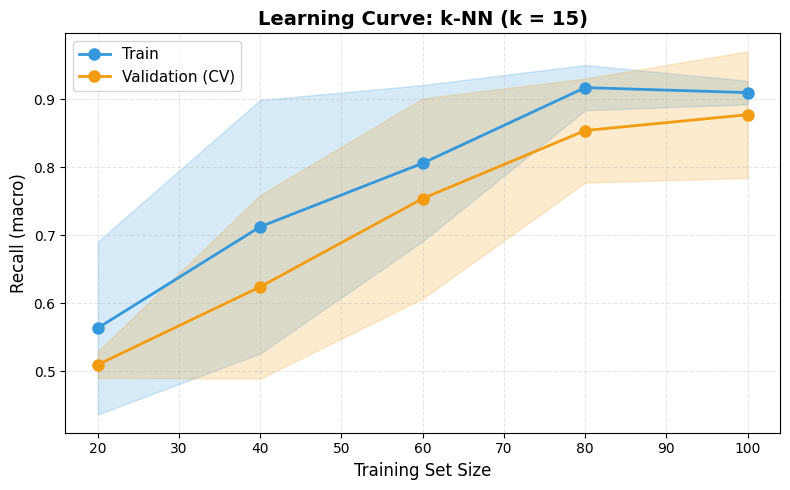

  Final train score: 0.910 ± 0.017
  Final validation score: 0.877 ± 0.093
  ✓ Small gap (0.033) suggests good generalization

Computing learning curve for Random Forest...


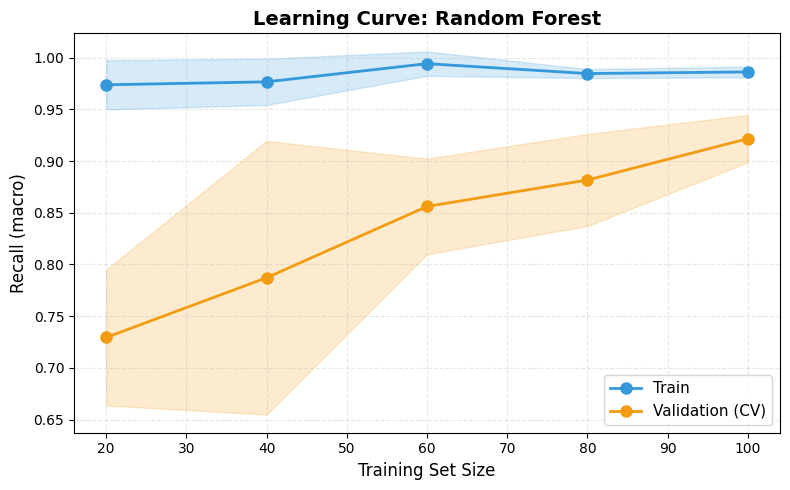

  Final train score: 0.986 ± 0.005
  Final validation score: 0.922 ± 0.023
  → Moderate gap (0.064)

Computing learning curve for SVC (RBF)...


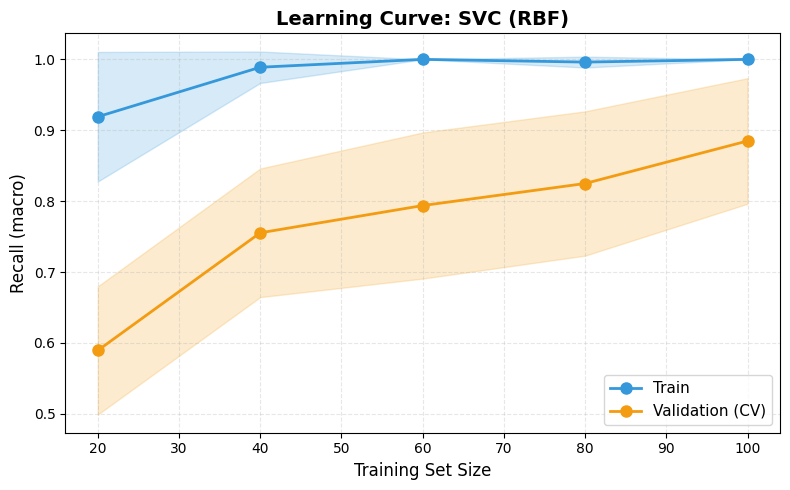

  Final train score: 1.000 ± 0.000
  Final validation score: 0.885 ± 0.089
  → Moderate gap (0.115)

Computing learning curve for Logistic Regression...


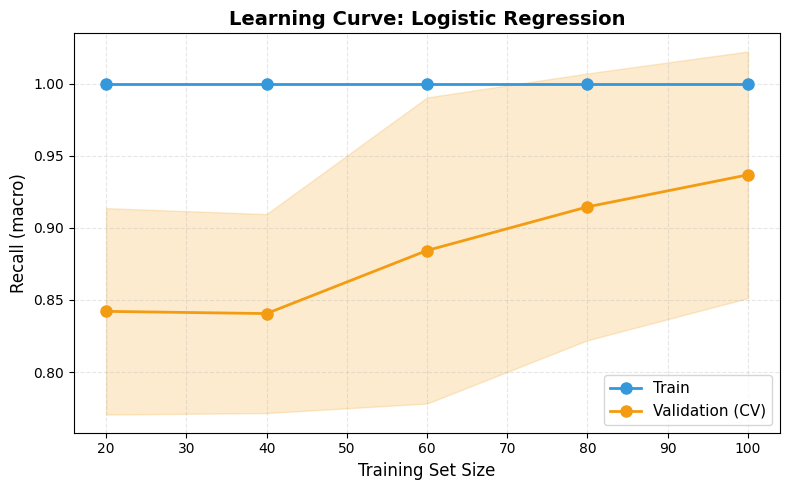

  Final train score: 1.000 ± 0.000
  Final validation score: 0.937 ± 0.086
  → Moderate gap (0.063)

LEARNING CURVE ANALYSIS COMPLETE

Interpretation:
  - If validation score plateaus early → model may need more data
  - If large gap between train/val → potential overfitting
  - If both scores are low → potential underfitting


In [34]:
# ============================================================================
# LEARNING CURVE COMPUTATION AND VISUALIZATION
# ============================================================================

train_sizes = np.linspace(0.2, 1.0, 5) 

# define CV for learning curves
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# compute learning curves for each baseline model
for model_name, model in baseline_models.items():
    print(f"\nComputing learning curve for {model_name}...")
    
    pipeline = make_baseline_pipeline(model)
    
    train_sizes_abs, train_scores, val_scores = learning_curve(
        pipeline,
        X_train_raw,
        y_train,
        train_sizes=train_sizes,
        cv=cv_lc,
        scoring='recall_macro',  # primary metric
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    
    # calculate stats
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    val_scores_mean = np.mean(val_scores, axis=1)
    val_scores_std = np.std(val_scores, axis=1)
    
    plt.figure(figsize=(8, 5))
    
    plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='#3498DB', 
             label='Train', linewidth=2, markersize=8)
    plt.fill_between(train_sizes_abs, 
                     train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std,
                     alpha=0.2, color='#3498DB')
    
    plt.plot(train_sizes_abs, val_scores_mean, 'o-', color='#F39C12',
             label='Validation (CV)', linewidth=2, markersize=8)
    plt.fill_between(train_sizes_abs,
                     val_scores_mean - val_scores_std,
                     val_scores_mean + val_scores_std,
                     alpha=0.2, color='#F39C12')
    
    plt.xlabel('Training Set Size', fontsize=12)
    plt.ylabel('Recall (macro)', fontsize=12)
    plt.title(f'Learning Curve: {model_name}', fontsize=14, fontweight='bold')
    plt.legend(loc='best', fontsize=11)
    plt.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    print(f"  Final train score: {train_scores_mean[-1]:.3f} ± {train_scores_std[-1]:.3f}")
    print(f"  Final validation score: {val_scores_mean[-1]:.3f} ± {val_scores_std[-1]:.3f}")
    
    # check for underfitting/overfitting
    gap = train_scores_mean[-1] - val_scores_mean[-1]
    if gap > 0.15:
        print(f"  ⚠️  Large gap ({gap:.3f}) suggests potential overfitting")
    elif gap < 0.05:
        print(f"  ✓ Small gap ({gap:.3f}) suggests good generalization")
    else:
        print(f"  → Moderate gap ({gap:.3f})")

print("\n" + "="*80)
print("LEARNING CURVE ANALYSIS COMPLETE")
print("="*80)
print("\nInterpretation:")
print("  - If validation score plateaus early → model may need more data")
print("  - If large gap between train/val → potential overfitting")
print("  - If both scores are low → potential underfitting")
print("="*80)

In [35]:
# ============================================================================
# LOADING FINETUNED MODEL
# ============================================================================
import os

model_path = 'best_model_finetuned.pkl'
metadata_path = 'model_metadata.pkl'

if not os.path.exists(model_path):
    raise FileNotFoundError(
        f"Model file '{model_path}' not found. "
        "Please run NEW-finetuning.ipynb first to train and save the model."
    )

if not os.path.exists(metadata_path):
    raise FileNotFoundError(
        f"Metadata file '{metadata_path}' not found. "
        "Please run NEW-finetuning.ipynb first to save model metadata."
    )

# Load the finetuned model (full pipeline: UncertaintyTransformer + StandardScaler + Classifier)
with open(model_path, 'rb') as f:
    finetuned_model = pickle.load(f)

# Load metadata
with open(metadata_path, 'rb') as f:
    model_metadata = pickle.load(f)

print("=" * 80)
print("LOADED FINETUNED MODEL FROM NEW-finetuning.ipynb")
print("=" * 80)
print(f"\nModel loaded from: {model_path}")
print(f"Metadata loaded from: {metadata_path}")
print(f"\nModel pipeline steps:")
for name, step in finetuned_model.named_steps.items():
    print(f"  - {name}: {type(step).__name__}")
print(f"\nMetadata:")
print(f"  - Features: {len(model_metadata['features'])} features")
print(f"  - Class labels: {model_metadata['class_labels']}")
print(f"  - N_BINS: {model_metadata['n_bins']}")
print(f"  - EPS: {model_metadata['eps']}")
print("=" * 80)
print("\nThe finetuned model is now available as 'finetuned_model' for use in this notebook.")

LOADED FINETUNED MODEL FROM NEW-finetuning.ipynb

Model loaded from: best_model_finetuned.pkl
Metadata loaded from: model_metadata.pkl

Model pipeline steps:
  - uncertainty: UncertaintyTransformer
  - scaler: StandardScaler
  - clf: VotingClassifier

Metadata:
  - Features: 54 features
  - Class labels: (np.int64(1), np.int64(2))
  - N_BINS: 20
  - EPS: 1e-12

The finetuned model is now available as 'finetuned_model' for use in this notebook.


In [36]:
# ============================================================================
# FINETUNED MODEL - CV PERFORMANCE ON TRAIN SET
# ============================================================================

from sklearn.model_selection import cross_validate

print("=" * 80)
print("FINETUNED MODEL - CV PERFORMANCE ON TRAIN SET")
print("=" * 80)

from sklearn.base import clone

print(f"\nModel: {model_metadata['model_name']}")

# clone handles VotingClassifier and single-clf pipelines alike
def make_finetuned_pipeline():
    """Create a fresh unfitted pipeline clone for CV / learning curve."""
    return clone(finetuned_model)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = cross_validate(
    make_finetuned_pipeline(),
    X_train_raw,
    y_train,
    cv=cv,
    scoring={
        'accuracy': 'accuracy',
        'precision_macro': 'precision_macro',
        'recall_macro': 'recall_macro',
        'f1_macro': 'f1_macro'
    },
    return_train_score=False,
    n_jobs=-1
)

print(f"\n5-Fold Stratified CV Results (mean ± std):")
print("-" * 40)
print(f"  Accuracy:  {cv_results['test_accuracy'].mean():.4f} ± {cv_results['test_accuracy'].std():.4f}")
print(f"  Precision: {cv_results['test_precision_macro'].mean():.4f} ± {cv_results['test_precision_macro'].std():.4f}")
print(f"  Recall:    {cv_results['test_recall_macro'].mean():.4f} ± {cv_results['test_recall_macro'].std():.4f}")
print(f"  F1-score:  {cv_results['test_f1_macro'].mean():.4f} ± {cv_results['test_f1_macro'].std():.4f}")
print("=" * 80)

FINETUNED MODEL - CV PERFORMANCE ON TRAIN SET

Model: VotingClassifier(LogisticRegression+SVC+KNeighborsClassifier)

5-Fold Stratified CV Results (mean ± std):
----------------------------------------
  Accuracy:  0.9680 ± 0.0466
  Precision: 0.9699 ± 0.0470
  Recall:    0.9604 ± 0.0557
  F1-score:  0.9643 ± 0.0520


LEARNING CURVE FOR FINETUNED MODEL
Model: VotingClassifier(LogisticRegression+SVC+KNeighborsClassifier)

Computing learning curve...


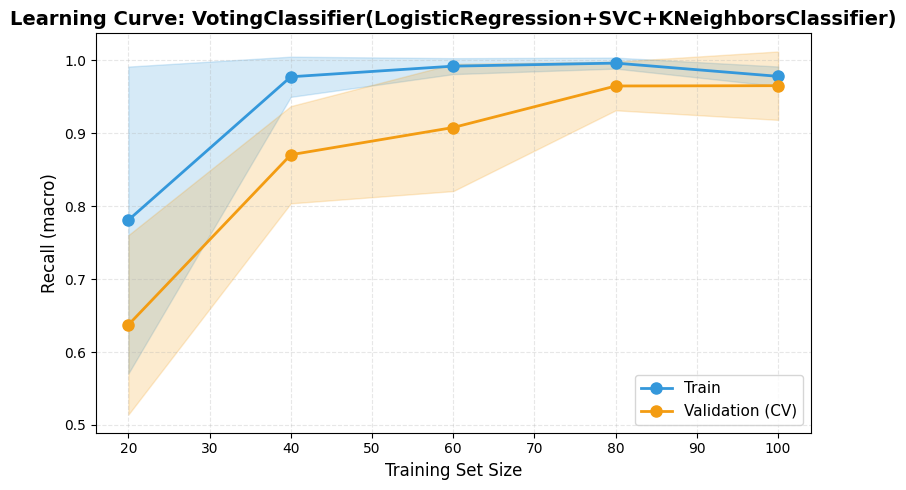


Final train score: 0.978 ± 0.013
Final validation score: 0.965 ± 0.047
✓ Small gap (0.013) suggests good generalization


In [37]:
# ============================================================================
# LEARNING CURVE FOR FINETUNED MODEL
# ============================================================================

print("=" * 80)
print("LEARNING CURVE FOR FINETUNED MODEL")
print("=" * 80)

# get the classifier from the finetuned pipeline to create fresh instances for LC
from sklearn.base import clone

print(f"Model: {model_metadata['model_name']}")

# clone handles VotingClassifier and single-clf pipelines alike
# compute learning curve
train_sizes_lc = np.linspace(0.2, 1.0, 5)
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("\nComputing learning curve...")

train_sizes_abs, train_scores, val_scores = learning_curve(
    make_finetuned_pipeline(),
    X_train_raw,
    y_train,
    train_sizes=train_sizes_lc,
    cv=cv_lc,
    scoring='recall_macro',
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

# calculate stats
train_scores_mean = np.mean(train_scores, axis=1)
train_scores_std = np.std(train_scores, axis=1)
val_scores_mean = np.mean(val_scores, axis=1)
val_scores_std = np.std(val_scores, axis=1)

plt.figure(figsize=(8, 5))

plt.plot(train_sizes_abs, train_scores_mean, 'o-', color='#3498DB', 
         label='Train', linewidth=2, markersize=8)
plt.fill_between(train_sizes_abs, 
                 train_scores_mean - train_scores_std,
                 train_scores_mean + train_scores_std,
                 alpha=0.2, color='#3498DB')

plt.plot(train_sizes_abs, val_scores_mean, 'o-', color='#F39C12',
         label='Validation (CV)', linewidth=2, markersize=8)
plt.fill_between(train_sizes_abs,
                 val_scores_mean - val_scores_std,
                 val_scores_mean + val_scores_std,
                 alpha=0.2, color='#F39C12')

plt.xlabel('Training Set Size', fontsize=12)
plt.ylabel('Recall (macro)', fontsize=12)
plt.title(f"Learning Curve: {model_metadata['model_name']}", fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=11)
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nFinal train score: {train_scores_mean[-1]:.3f} ± {train_scores_std[-1]:.3f}")
print(f"Final validation score: {val_scores_mean[-1]:.3f} ± {val_scores_std[-1]:.3f}")

# check for underfitting/overfitting
gap = train_scores_mean[-1] - val_scores_mean[-1]
if gap > 0.15:
    print(f"  Large gap ({gap:.3f}) suggests potential overfitting")
elif gap < 0.05:
    print(f"✓ Small gap ({gap:.3f}) suggests good generalization")
else:
    print(f"→ Moderate gap ({gap:.3f})")

print("=" * 80)